## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [1]:
# Imports
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
alcohol_stats = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"
alcohol = pd.read_csv(alcohol_stats)

In [31]:
# Look at the dataset
alcohol.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [2]:
# Drop the total_litres_of_pure_alcohol column from alcohol
alcohol = alcohol.drop(columns="total_litres_of_pure_alcohol")

# Tidy the data with melt
tidy_alcohol = alcohol.melt(
    id_vars="country",
    var_name="drink",
    value_name="servings"
)
tidy_alcohol

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

1. Based on my top10_alcohol data: 
    The country that drinks the most beer is Namibia,
    the country that drinks the most wine is France,
    and the country that drinks the most spirits is Grenada

,country,drink,servings
0,Namibia,beer,376
1,Czech Republic,beer,361
2,Gabon,beer,347
3,Germany,beer,346
4,Lithuania,beer,343
5,Poland,beer,343
6,Venezuela,beer,333
7,Ireland,beer,313
8,Palau,beer,306
9,Romania,beer,297


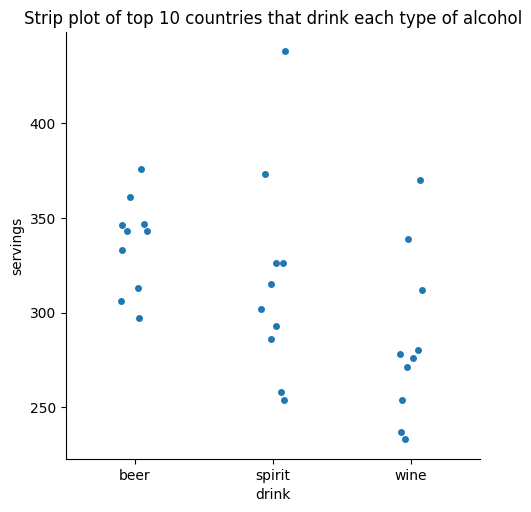

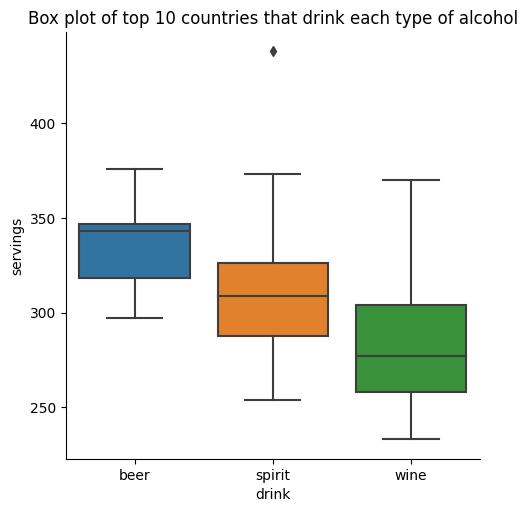

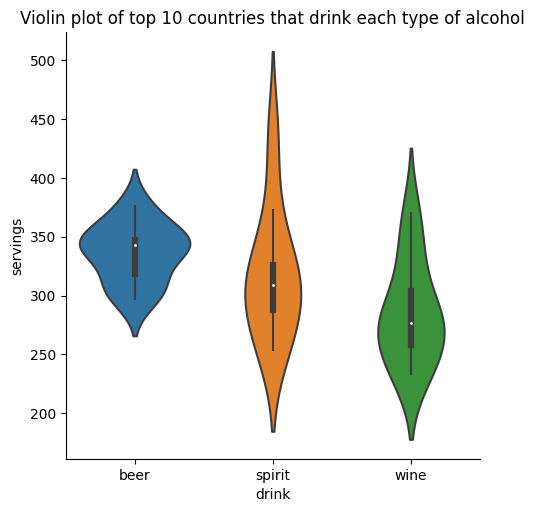

In [3]:
# Remove the "_servings" from the drink column
tidy_alcohol["drink"] = tidy_alcohol["drink"].str.replace("_servings", "")
# tidy_alcohol

# Create a new dataframe with the top 10 countries for each drink type
top10_alcohol = tidy_alcohol.groupby("drink").apply(lambda x: x.nlargest(10, "servings")).reset_index(drop=True)

# Graph 1: Strip  plot (default catplot)
sns.catplot(
    data=top10_alcohol,
    x="drink",
    y="servings",
)
plt.title("Strip plot of top 10 countries that drink each type of alcohol")

# Graph 2: Box plot
sns.catplot(
    data=top10_alcohol,
    x="drink",
    y="servings",
    kind="box",
)
plt.title("Box plot of top 10 countries that drink each type of alcohol")

# Graph 3: Violin plot
sns.catplot(
    data=top10_alcohol,
    x="drink",
    y="servings",
    kind="violin"
)
plt.title("Violin plot of top 10 countries that drink each type of alcohol")

top10_alcohol

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [8]:
# Use a pivot table to make a wide format of the tidy_alcohol dataframe
wide_alcohol = tidy_alcohol.pivot_table(
    index="country",
    columns="drink",
    values="servings"
)

# Reset the index of the wide_alcohol dataframe
wide_alcohol.reset_index(inplace=True)

wide_alcohol

drink,country,beer,spirit,wine
0,Afghanistan,0,0,0
1,Albania,89,132,54
2,Algeria,25,0,14
3,Andorra,245,138,312
4,Angola,217,57,45
...,...,...,...,...
188,Venezuela,333,100,3
189,Vietnam,111,2,1
190,Yemen,6,0,0
191,Zambia,32,19,4
